# 17. Non-apical chord topology groups vs LV geometry and mechanics

## Цель ноутбука

В этом ноутбуке проверяется новая механистическая классификация архитектуры ложных хорд ЛЖ.

Основная идея:

Мы не рассматриваем хорды как патологию и не сравниваем пациентов по принципу “хуже/лучше”.
Мы проверяем, связана ли топологическая сложность неапикальной архитектуры хорд с геометрией ЛЖ, напряжением стенки и региональной механической неоднородностью.

## Новая рабочая классификация

### Group 1 — Local-simple chord architecture

Наблюдения с простой локальной архитектурой:

- 1 хорда;
- и/или 2 хорды, которые затрагивают только соседние уровни/регионы ЛЖ;
- без дальнего basal–apical bridge;
- без чисто апикального фенотипа.

Физиологический смысл:
локальная или почти локальная механическая связь без выраженного распределённого сетевого эффекта.

---

### Group 2 — Intermediate focal / bridge architecture

Промежуточная архитектура:

- 2 хорды только в одном регионе;
- 2 хорды с комбинацией orientation-паттернов:
  - transverse + transverse;
  - oblique + oblique;
  - transverse + oblique;
  но только в пределах одного региона;
- 1 хорда, соединяющая противоположные уровни/регионы, например basal–apical bridge.

Физиологический смысл:
либо локально усиленное tethering-ограничение, либо одиночный дальний механический мост.

---

### Group 3 — Distributed non-apical chord network

Все остальные случаи, которые не попали в первые две группы,
но при этом не являются чисто апикальными.

Физиологический смысл:
более сложная распределённая неапикальная сеть хорд.

---

## Outcomes

Проверяем связь новых групп с переменными:

- `echo_lv_sphericity_index_end_diastolic_ratio`
- `echo_lv_sphericity_index_end_systolic_ratio`
- `echo_lv_myocardial_mass_index_g_m2`
- `echo_lv_sws_delta_g_cm2`
- `merged_lv_deformation_cv_pct`
- `dicor_sm_kdtr_cv_pct`

## Важное методическое замечание

Это exploratory-анализ. 
Главная задача — не доказать причинность, а понять, дают ли новые топологические группы более физиологически осмысленный сигнал, чем прежние грубые классификации.

In [1]:
# ============================================================
# 17. Non-apical chord topology groups vs LV geometry/mechanics
# ============================================================

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Paths
# ----------------------------

PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DATA_PATH = DATA_DIR / "final_analysis_dataset_ver2.xlsx"

# Если файл с механистическими признаками лежит в другом месте — поправить здесь.
MECH_DATA_PATH = DATA_DIR / "processed" / "regression_mechanistic_dataset.xlsx"

if not MECH_DATA_PATH.exists():
    MECH_DATA_PATH = DATA_DIR / "regression_mechanistic_dataset.xlsx"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FINAL_DATA_PATH exists:", FINAL_DATA_PATH.exists(), FINAL_DATA_PATH)
print("MECH_DATA_PATH exists:", MECH_DATA_PATH.exists(), MECH_DATA_PATH)

PROJECT_ROOT: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords
FINAL_DATA_PATH exists: True C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
MECH_DATA_PATH exists: False C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\regression_mechanistic_dataset.xlsx


In [2]:
# ----------------------------
# Academic plotting style
# ----------------------------

sns.set_theme(
    context="paper",
    style="white",
    font_scale=1.15,
)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (7.2, 4.8),

    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,

    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,

    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.color": "black",
    "ytick.color": "black",

    "legend.frameon": False,
})

GROUP_ORDER = [
    "1_Local_simple",
    "2_Intermediate_focal_or_bridge",
    "3_Distributed_non_apical_network",
]

GROUP_LABELS_RU = {
    "1_Local_simple": "1. Локально-простая",
    "2_Intermediate_focal_or_bridge": "2. Промежуточная\nлокальная/мостовая",
    "3_Distributed_non_apical_network": "3. Распределённая\nнеапикальная сеть",
}

OUTCOME_LABELS_RU = {
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_myocardial_mass_index_g_m2": "Индекс массы миокарда ЛЖ, г/м²",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "merged_lv_deformation_cv_pct": "CV деформации ЛЖ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR KDTR CV, %",
}

In [3]:
# ----------------------------
# Load data
# ----------------------------

df_final = pd.read_excel(FINAL_DATA_PATH)
print("df_final:", df_final.shape)

if MECH_DATA_PATH.exists():
    df_mech = pd.read_excel(MECH_DATA_PATH)
    print("df_mech:", df_mech.shape)
else:
    df_mech = None
    print("WARNING: mechanistic dataset was not found. Will use df_final only.")

display(df_final.head())

df_final: (153, 222)


,subject_full_name,age,height_cm,weight_cm,BSA,sex,IMT,echo_ascending_aorta_diameter_mm_div_bsa,echo_ascending_aorta_diameter_mm,echo_aortic_sinus_diameter_mm_div_bsa,...,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,echo_lv_systolic_wall_stress_g_cm2,merged_lv_deformation_cv_pct,hemo_sbp_rest_mmhg,hemo_sbp_exercise_mmhg,dsws,echo_lv_sws_rest_g_cm2,echo_lv_sws_max_g_cm2,echo_lv_sws_delta_g_cm2
0,Абатурова,23.0,176.0,70.0,1.849925,1.0,23.0,14.054624,26.0,13.514062,...,NaN,NaN,114.446420,24.0,122.0,159.0,37.0,116.630910,152.002579,35.371669
1,Абросимова,15.0,163.0,62.0,1.675477,1.0,23.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Айтиева,20.0,155.0,58.5,1.587057,1.0,24.5,16.382524,26.0,16.382524,...,NaN,NaN,169.629253,37.0,119.0,161.0,42.0,109.309091,147.888770,38.579679
3,Алиева,21.0,152.0,53.3,1.500148,1.0,23.0,17.331622,26.0,15.331819,...,NaN,NaN,67.794404,33.0,109.0,155.0,46.0,96.054733,136.591592,40.536860
4,Артемова,17.0,161.0,55.0,1.568350,1.0,21.0,13.389867,21.0,13.389867,...,NaN,NaN,96.909213,NaN,118.0,139.0,21.0,75.558075,101.839145,26.281070


In [4]:
# ----------------------------
# Merge mechanistic features if available
# ----------------------------

ID_COL = "subject_full_name"

candidate_mech_cols = [
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "tethering_index",
]

if df_mech is not None:
    existing_mech_cols = [c for c in candidate_mech_cols if c in df_mech.columns]

    print("Existing mechanistic cols in df_mech:")
    print(existing_mech_cols)

    if ID_COL in df_final.columns and ID_COL in df_mech.columns:
        df = df_final.merge(
            df_mech[[ID_COL] + existing_mech_cols],
            on=ID_COL,
            how="left",
            validate="one_to_one",
            suffixes=("", "_mech"),
        )
        print("Merged by subject_full_name:", df.shape)
    else:
        # Fallback: only if row order is known to be identical.
        print("WARNING: subject_full_name not found in both datasets. Using row-order fallback.")
        df = df_final.copy()
        for col in existing_mech_cols:
            if col not in df.columns:
                df[col] = df_mech[col].values
else:
    df = df_final.copy()

print("Final working df:", df.shape)

Final working df: (153, 222)


In [5]:
# ----------------------------
# Detect segment-level chord attachment columns
# ----------------------------

attachment_cols = [
    c for c in df.columns
    if ("chord_attachment" in c.lower()) or ("attachment_flag" in c.lower() and "chord" in c.lower())
]

basal_attachment_cols = [c for c in attachment_cols if "_basal_" in c.lower()]
mid_attachment_cols = [c for c in attachment_cols if "_mid_" in c.lower()]
apical_attachment_cols = [c for c in attachment_cols if "_apical_" in c.lower()]

print("All attachment cols:", len(attachment_cols))
print("Basal attachment cols:", len(basal_attachment_cols))
print("Mid attachment cols:", len(mid_attachment_cols))
print("Apical attachment cols:", len(apical_attachment_cols))

print("\nBasal:")
print(basal_attachment_cols)

print("\nMid:")
print(mid_attachment_cols)

print("\nApical:")
print(apical_attachment_cols)

All attachment cols: 18
Basal attachment cols: 6
Mid attachment cols: 6
Apical attachment cols: 6

Basal:
['strain_plus_basal_anteroseptal_chord_attachment_flag', 'strain_plus_basal_anterior_chord_attachment_flag', 'strain_plus_basal_anterolateral_chord_attachment_flag', 'strain_plus_basal_inferolateral_chord_attachment_flag', 'strain_plus_basal_inferior_chord_attachment_flag', 'strain_plus_basal_inferoseptal_chord_attachment_flag']

Mid:
['strain_plus_mid_anteroseptal_chord_attachment_flag', 'strain_plus_mid_anterior_chord_attachment_flag', 'strain_plus_mid_anterolateral_chord_attachment_flag', 'strain_plus_mid_inferolateral_chord_attachment_flag', 'strain_plus_mid_inferior_chord_attachment_flag', 'strain_plus_mid_inferoseptal_chord_attachment_flag']

Apical:
['strain_plus_apical_anteroseptal_chord_attachment_flag', 'strain_plus_apical_anterior_chord_attachment_flag', 'strain_plus_apical_anterolateral_chord_attachment_flag', 'strain_plus_apical_inferolateral_chord_attachment_flag', 's

In [6]:
# ----------------------------
# Helper functions
# ----------------------------

def row_any_positive(row, cols):
    if not cols:
        return False
    values = pd.to_numeric(row[cols], errors="coerce").fillna(0)
    return bool((values > 0).any())


def row_sum_positive(row, cols):
    if not cols:
        return np.nan
    values = pd.to_numeric(row[cols], errors="coerce").fillna(0)
    return int((values > 0).sum())


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


# ----------------------------
# Create attachment-level variables
# ----------------------------

df["has_basal_chord_attachment"] = df.apply(lambda r: row_any_positive(r, basal_attachment_cols), axis=1)
df["has_mid_chord_attachment"] = df.apply(lambda r: row_any_positive(r, mid_attachment_cols), axis=1)
df["has_apical_chord_attachment"] = df.apply(lambda r: row_any_positive(r, apical_attachment_cols), axis=1)

df["n_basal_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, basal_attachment_cols), axis=1)
df["n_mid_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, mid_attachment_cols), axis=1)
df["n_apical_chord_attachment_segments"] = df.apply(lambda r: row_sum_positive(r, apical_attachment_cols), axis=1)

df["n_chord_attachment_segments_total"] = (
    df["n_basal_chord_attachment_segments"].fillna(0)
    + df["n_mid_chord_attachment_segments"].fillna(0)
    + df["n_apical_chord_attachment_segments"].fillna(0)
)

df["n_involved_lv_levels"] = (
    df[[
        "has_basal_chord_attachment",
        "has_mid_chord_attachment",
        "has_apical_chord_attachment",
    ]]
    .astype(int)
    .sum(axis=1)
)

df["is_pure_apical_chord_topology"] = (
    df["has_apical_chord_attachment"]
    & ~df["has_basal_chord_attachment"]
    & ~df["has_mid_chord_attachment"]
)

df["has_basal_mid_pattern"] = df["has_basal_chord_attachment"] & df["has_mid_chord_attachment"] & ~df["has_apical_chord_attachment"]
df["has_mid_apical_pattern"] = ~df["has_basal_chord_attachment"] & df["has_mid_chord_attachment"] & df["has_apical_chord_attachment"]
df["has_basal_apical_bridge_proxy"] = df["has_basal_chord_attachment"] & df["has_apical_chord_attachment"]

# Numeric chord variables
for col in [
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "tethering_index",
]:
    if col in df.columns:
        df[col] = safe_numeric(df[col])

topology_audit_cols = [
    "has_basal_chord_attachment",
    "has_mid_chord_attachment",
    "has_apical_chord_attachment",
    "is_pure_apical_chord_topology",
    "has_basal_mid_pattern",
    "has_mid_apical_pattern",
    "has_basal_apical_bridge_proxy",
    "n_involved_lv_levels",
    "n_chord_attachment_segments_total",
]

display(df[topology_audit_cols].describe(include="all"))

,has_basal_chord_attachment,has_mid_chord_attachment,has_apical_chord_attachment,is_pure_apical_chord_topology,has_basal_mid_pattern,has_mid_apical_pattern,has_basal_apical_bridge_proxy,n_involved_lv_levels,n_chord_attachment_segments_total
count,153,153,153,153,153,153,153,153.000000,153.000000
unique,2,2,2,1,2,1,2,NaN,NaN
top,False,False,False,False,False,False,False,NaN,NaN
freq,131,130,140,153,146,153,140,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.379085,0.745098
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.873638,1.695697
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000


In [13]:
# ============================================================
# Audit 1: group sizes
# ============================================================

group_col = "non_apical_chord_topology_group"

print("Group counts, including excluded/missing:")
display(
    df[group_col]
    .value_counts(dropna=False)
    .rename_axis(group_col)
    .reset_index(name="n")
)

print("\nGroup percentages:")
display(
    (df[group_col]
     .value_counts(dropna=False, normalize=True)
     .mul(100)
     .round(1)
     .rename_axis(group_col)
     .reset_index(name="percent"))
)

Group counts, including excluded/missing:


,non_apical_chord_topology_group,n
0,3_Distributed_non_apical_network,122
1,1_Local_simple,28
2,2_Intermediate_focal_or_bridge,3



Group percentages:


,non_apical_chord_topology_group,percent
0,3_Distributed_non_apical_network,79.7
1,1_Local_simple,18.3
2,2_Intermediate_focal_or_bridge,2.0


In [14]:
# ============================================================
# Audit 2: n per group for each outcome
# ============================================================

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

rows = []

for y in OUTCOMES:
    if y not in df.columns:
        continue

    temp = df[[group_col, y]].dropna()

    counts = temp[group_col].value_counts(dropna=False).to_dict()

    row = {
        "outcome": y,
        "n_total": len(temp),
        "n_group_1": counts.get("1_Local_simple", 0),
        "n_group_2": counts.get("2_Intermediate_focal_or_bridge", 0),
        "n_group_3": counts.get("3_Distributed_non_apical_network", 0),
        "n_missing_group": counts.get(np.nan, 0),
    }

    rows.append(row)

n_by_outcome = pd.DataFrame(rows)
display(n_by_outcome)

,outcome,n_total,n_group_1,n_group_2,n_group_3,n_missing_group
0,echo_lv_sphericity_index_end_diastolic_ratio,100,23,3,74,0
1,echo_lv_sphericity_index_end_systolic_ratio,100,23,3,74,0
2,echo_lv_myocardial_mass_index_g_m2,83,10,0,73,0
3,echo_lv_sws_delta_g_cm2,33,6,0,27,0
4,merged_lv_deformation_cv_pct,100,22,3,75,0
5,dicor_sm_kdtr_cv_pct,68,14,0,54,0


In [15]:
def classify_non_apical_chord_topology_with_reason(row):
    total_chords = row.get("lv_false_tendon_total_count", np.nan)

    pure_apical = bool(row.get("is_pure_apical_chord_topology", False))
    has_basal = bool(row.get("has_basal_chord_attachment", False))
    has_mid = bool(row.get("has_mid_chord_attachment", False))
    has_apical = bool(row.get("has_apical_chord_attachment", False))
    basal_apical_bridge = bool(row.get("has_basal_apical_bridge_proxy", False))

    if pure_apical:
        return pd.Series([np.nan, "excluded_pure_apical"])

    if pd.isna(total_chords):
        if basal_apical_bridge:
            return pd.Series(["2_Intermediate_focal_or_bridge", "missing_count_basal_apical_proxy"])
        return pd.Series(["3_Distributed_non_apical_network", "missing_count_residual_to_group_3"])

    if total_chords == 1 and basal_apical_bridge:
        return pd.Series(["2_Intermediate_focal_or_bridge", "single_basal_apical_bridge_proxy"])

    if total_chords == 1 and not basal_apical_bridge:
        return pd.Series(["1_Local_simple", "single_non_bridge"])

    if total_chords == 2:
        same_level_non_apical = (
            (has_basal and not has_mid and not has_apical)
            or (has_mid and not has_basal and not has_apical)
        )

        basal_mid_only = has_basal and has_mid and not has_apical

        if same_level_non_apical:
            return pd.Series(["2_Intermediate_focal_or_bridge", "two_chords_same_non_apical_level"])

        if basal_mid_only and not basal_apical_bridge:
            return pd.Series(["1_Local_simple", "two_chords_adjacent_basal_mid"])

    return pd.Series(["3_Distributed_non_apical_network", "residual_complex_non_apical"])


df[["non_apical_chord_topology_group_v2", "topology_classification_reason"]] = (
    df.apply(classify_non_apical_chord_topology_with_reason, axis=1)
)

display(
    pd.crosstab(
        df["non_apical_chord_topology_group_v2"],
        df["topology_classification_reason"],
        dropna=False
    )
)

topology_classification_reason,missing_count_residual_to_group_3,residual_complex_non_apical,single_basal_apical_bridge_proxy,single_non_bridge,two_chords_adjacent_basal_mid,two_chords_same_non_apical_level
non_apical_chord_topology_group_v2,,,,,,
1_Local_simple,0,0,0,22,6,0
2_Intermediate_focal_or_bridge,0,0,1,0,0,2
3_Distributed_non_apical_network,21,101,0,0,0,0


In [7]:
# ----------------------------
# Define new topology groups
# ----------------------------

def classify_non_apical_chord_topology(row):
    """
    Working exploratory classification.

    Exclusion:
    - Pure apical topology is excluded from the classification.

    Group 1:
    - 1 chord with local/adjacent non-apical topology;
    - or 2 chords involving only adjacent non-apical levels;
    - no basal-apical bridge proxy.

    Group 2:
    - 2 chords in one region/level;
    - or 2 chords with focal orientation pattern in one region;
    - or 1 chord with basal-apical bridge proxy.

    Group 3:
    - everything else that is not pure apical and not group 1/2.
    """

    total_chords = row.get("lv_false_tendon_total_count", np.nan)
    transverse_load = row.get("transverse_load", np.nan)
    oblique_load = row.get("oblique_load", np.nan)

    n_levels = row.get("n_involved_lv_levels", np.nan)
    n_attach_segments = row.get("n_chord_attachment_segments_total", np.nan)

    pure_apical = bool(row.get("is_pure_apical_chord_topology", False))
    has_basal = bool(row.get("has_basal_chord_attachment", False))
    has_mid = bool(row.get("has_mid_chord_attachment", False))
    has_apical = bool(row.get("has_apical_chord_attachment", False))
    basal_apical_bridge = bool(row.get("has_basal_apical_bridge_proxy", False))

    # 0. Exclude pure apical
    if pure_apical:
        return np.nan

    # If total chord count is missing, still allow classification by attachment topology,
    # but mark difficult cases as group 3.
    if pd.isna(total_chords):
        if basal_apical_bridge:
            return "2_Intermediate_focal_or_bridge"
        return "3_Distributed_non_apical_network"

    # 1. Single long bridge: group 2
    if total_chords == 1 and basal_apical_bridge:
        return "2_Intermediate_focal_or_bridge"

    # 2. Local-simple
    # One chord without basal-apical bridge
    if total_chords == 1 and not basal_apical_bridge:
        return "1_Local_simple"

    # Two chords involving only neighboring non-apical levels:
    # basal only, mid only, or basal+mid without apical.
    if total_chords == 2:
        non_apical_adjacent_or_focal = (
            (has_basal and not has_mid and not has_apical)
            or (has_mid and not has_basal and not has_apical)
            or (has_basal and has_mid and not has_apical)
        )

        # Same-level / focal two-chord architecture: group 2
        same_level_non_apical = (
            (has_basal and not has_mid and not has_apical)
            or (has_mid and not has_basal and not has_apical)
        )

        if same_level_non_apical:
            return "2_Intermediate_focal_or_bridge"

        if non_apical_adjacent_or_focal and not basal_apical_bridge:
            return "1_Local_simple"

    # 3. Everything else non-pure-apical
    return "3_Distributed_non_apical_network"


df["non_apical_chord_topology_group"] = df.apply(classify_non_apical_chord_topology, axis=1)

group_counts = (
    df["non_apical_chord_topology_group"]
    .value_counts(dropna=False)
    .rename_axis("non_apical_chord_topology_group")
    .reset_index(name="n")
)

display(group_counts)

group_counts.to_excel(
    TABLES_DIR / "17_non_apical_chord_topology_group_counts.xlsx",
    index=False,
)

,non_apical_chord_topology_group,n
0,3_Distributed_non_apical_network,122
1,1_Local_simple,28
2,2_Intermediate_focal_or_bridge,3


In [8]:
# ----------------------------
# Classification audit
# ----------------------------

audit_cols = [
    ID_COL,
    "non_apical_chord_topology_group",
    "lv_false_tendon_total_count",
    "transverse_load",
    "oblique_load",
    "long_oblique_bridge_load",
    "chord_type_diversity",
    "mechanical_chord_phenotype",
    "chord_type_complexity_class",
    "has_basal_chord_attachment",
    "has_mid_chord_attachment",
    "has_apical_chord_attachment",
    "is_pure_apical_chord_topology",
    "has_basal_apical_bridge_proxy",
    "n_involved_lv_levels",
    "n_chord_attachment_segments_total",
]

audit_cols = [c for c in audit_cols if c in df.columns]

classification_audit = df[audit_cols].copy()

display(classification_audit.head(20))

classification_audit.to_excel(
    TABLES_DIR / "17_non_apical_chord_topology_classification_audit.xlsx",
    index=False,
)

# Cross-tabs with previous classifications
for col in ["mechanical_chord_phenotype", "chord_type_complexity_class"]:
    if col in df.columns:
        print("\n", "=" * 80)
        print(f"Cross-tab: non_apical_chord_topology_group × {col}")
        display(pd.crosstab(df["non_apical_chord_topology_group"], df[col], dropna=False))

,subject_full_name,non_apical_chord_topology_group,lv_false_tendon_total_count,has_basal_chord_attachment,has_mid_chord_attachment,has_apical_chord_attachment,is_pure_apical_chord_topology,has_basal_apical_bridge_proxy,n_involved_lv_levels,n_chord_attachment_segments_total
0,Абатурова,1_Local_simple,1.0,False,False,False,False,False,0,0
1,Абросимова,3_Distributed_non_apical_network,2.0,False,False,False,False,False,0,0
2,Айтиева,3_Distributed_non_apical_network,4.0,False,False,False,False,False,0,0
3,Алиева,3_Distributed_non_apical_network,3.0,False,False,False,False,False,0,0
4,Артемова,3_Distributed_non_apical_network,3.0,False,False,False,False,False,0,0
5,Бирюкова,3_Distributed_non_apical_network,4.0,False,False,False,False,False,0,0
6,Бузакова,3_Distributed_non_apical_network,2.0,False,False,False,False,False,0,0
7,Булатова,3_Distributed_non_apical_network,2.0,False,False,False,False,False,0,0
8,Варвашеня,3_Distributed_non_apical_network,4.0,False,False,False,False,False,0,0
9,Волкова,3_Distributed_non_apical_network,NaN,False,False,False,False,False,0,0


In [9]:
# ----------------------------
# Outcomes
# ----------------------------

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

existing_outcomes = [c for c in OUTCOMES if c in df.columns]
missing_outcomes = [c for c in OUTCOMES if c not in df.columns]

print("Existing outcomes:")
print(existing_outcomes)

print("\nMissing outcomes:")
print(missing_outcomes)

for col in existing_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")

availability = []

for y in existing_outcomes:
    temp = df[["non_apical_chord_topology_group", y]].dropna()
    availability.append({
        "outcome": y,
        "n_total_available": len(temp),
        **temp["non_apical_chord_topology_group"].value_counts().to_dict()
    })

availability_df = pd.DataFrame(availability)
display(availability_df)

availability_df.to_excel(
    TABLES_DIR / "17_outcome_availability_by_topology_group.xlsx",
    index=False,
)

Existing outcomes:
['echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_myocardial_mass_index_g_m2', 'echo_lv_sws_delta_g_cm2', 'merged_lv_deformation_cv_pct', 'dicor_sm_kdtr_cv_pct']

Missing outcomes:
[]


,outcome,n_total_available,3_Distributed_non_apical_network,1_Local_simple,2_Intermediate_focal_or_bridge
0,echo_lv_sphericity_index_end_diastolic_ratio,100,74,23,3.0
1,echo_lv_sphericity_index_end_systolic_ratio,100,74,23,3.0
2,echo_lv_myocardial_mass_index_g_m2,83,73,10,NaN
3,echo_lv_sws_delta_g_cm2,33,27,6,NaN
4,merged_lv_deformation_cv_pct,100,75,22,3.0
5,dicor_sm_kdtr_cv_pct,68,54,14,NaN


In [10]:
# ----------------------------
# Descriptive statistics and non-parametric screening
# ----------------------------

def cliffs_delta(x, y):
    """
    Cliff's delta effect size for two independent samples.
    Positive value means x tends to be greater than y.
    """
    x = np.asarray(pd.Series(x).dropna())
    y = np.asarray(pd.Series(y).dropna())

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)

    return (gt - lt) / (len(x) * len(y))


summary_rows = []
test_rows = []
pairwise_rows = []

for y in existing_outcomes:
    temp = df[["non_apical_chord_topology_group", y]].dropna().copy()
    temp = temp[temp["non_apical_chord_topology_group"].isin(GROUP_ORDER)]

    # Descriptive stats
    desc = (
        temp
        .groupby("non_apical_chord_topology_group")[y]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    desc["outcome"] = y
    summary_rows.append(desc)

    # Kruskal-Wallis
    arrays = [
        temp.loc[temp["non_apical_chord_topology_group"] == g, y].dropna()
        for g in GROUP_ORDER
    ]
    arrays_nonempty = [a for a in arrays if len(a) > 0]

    if len(arrays_nonempty) >= 2:
        kw_stat, kw_p = stats.kruskal(*arrays_nonempty)
    else:
        kw_stat, kw_p = np.nan, np.nan

    test_rows.append({
        "outcome": y,
        "n": len(temp),
        "kruskal_h": kw_stat,
        "kruskal_p": kw_p,
    })

    # Pairwise Mann-Whitney + Cliff's delta
    for i, g1 in enumerate(GROUP_ORDER):
        for g2 in GROUP_ORDER[i + 1:]:
            x = temp.loc[temp["non_apical_chord_topology_group"] == g1, y].dropna()
            z = temp.loc[temp["non_apical_chord_topology_group"] == g2, y].dropna()

            if len(x) >= 2 and len(z) >= 2:
                u_stat, p_val = stats.mannwhitneyu(x, z, alternative="two-sided")
                cd = cliffs_delta(x, z)
            else:
                u_stat, p_val, cd = np.nan, np.nan, np.nan

            pairwise_rows.append({
                "outcome": y,
                "group_1": g1,
                "group_2": g2,
                "n_1": len(x),
                "n_2": len(z),
                "median_1": np.nanmedian(x) if len(x) else np.nan,
                "median_2": np.nanmedian(z) if len(z) else np.nan,
                "median_diff_1_minus_2": (
                    np.nanmedian(x) - np.nanmedian(z)
                    if len(x) and len(z)
                    else np.nan
                ),
                "mannwhitney_u": u_stat,
                "p_value": p_val,
                "cliffs_delta": cd,
            })

summary_df = pd.concat(summary_rows, ignore_index=True)
tests_df = pd.DataFrame(test_rows)
pairwise_df = pd.DataFrame(pairwise_rows)

display(summary_df)
display(tests_df.sort_values("kruskal_p"))
display(pairwise_df.sort_values("p_value"))

summary_df.to_excel(TABLES_DIR / "17_descriptive_stats_by_topology_group.xlsx", index=False)
tests_df.to_excel(TABLES_DIR / "17_kruskal_tests_by_topology_group.xlsx", index=False)
pairwise_df.to_excel(TABLES_DIR / "17_pairwise_tests_by_topology_group.xlsx", index=False)

,non_apical_chord_topology_group,count,mean,std,median,min,max,outcome
0,1_Local_simple,23,0.519130,0.068235,0.519000,0.343000,0.642000,echo_lv_sphericity_index_end_diastolic_ratio
1,2_Intermediate_focal_or_bridge,3,0.546667,0.065064,0.550000,0.480000,0.610000,echo_lv_sphericity_index_end_diastolic_ratio
2,3_Distributed_non_apical_network,74,0.522973,0.070729,0.514500,0.370000,0.709000,echo_lv_sphericity_index_end_diastolic_ratio
3,1_Local_simple,23,0.455739,0.075161,0.450000,0.328000,0.590000,echo_lv_sphericity_index_end_systolic_ratio
4,2_Intermediate_focal_or_bridge,3,0.515000,0.106419,0.535000,0.400000,0.610000,echo_lv_sphericity_index_end_systolic_ratio
5,3_Distributed_non_apical_network,74,0.458419,0.082068,0.439500,0.330000,0.650000,echo_lv_sphericity_index_end_systolic_ratio
6,1_Local_simple,10,84.000000,21.499354,84.500000,58.000000,120.000000,echo_lv_myocardial_mass_index_g_m2
7,3_Distributed_non_apical_network,73,81.205479,15.822767,77.000000,56.000000,147.000000,echo_lv_myocardial_mass_index_g_m2
8,1_Local_simple,6,24.255056,14.732182,24.615650,5.994872,39.878423,echo_lv_sws_delta_g_cm2
9,3_Distributed_non_apical_network,27,26.618581,24.124824,21.944419,3.042909,135.312821,echo_lv_sws_delta_g_cm2


,outcome,n,kruskal_h,kruskal_p
4,merged_lv_deformation_cv_pct,100,2.681091,0.261703
1,echo_lv_sphericity_index_end_systolic_ratio,100,1.259321,0.532773
5,dicor_sm_kdtr_cv_pct,68,0.243049,0.622013
0,echo_lv_sphericity_index_end_diastolic_ratio,100,0.502629,0.777778
2,echo_lv_myocardial_mass_index_g_m2,83,0.047052,0.828275
3,echo_lv_sws_delta_g_cm2,33,0.002179,0.962771


,outcome,group_1,group_2,n_1,n_2,median_1,median_2,median_diff_1_minus_2,mannwhitney_u,p_value,cliffs_delta
14,merged_lv_deformation_cv_pct,2_Intermediate_focal_or_bridge,3_Distributed_non_apical_network,3,75,18.377448,27.992261,-9.614812,58.0,0.160360,-0.484444
12,merged_lv_deformation_cv_pct,1_Local_simple,2_Intermediate_focal_or_bridge,22,3,21.967337,18.377448,3.589888,47.0,0.258654,0.424242
3,echo_lv_sphericity_index_end_systolic_ratio,1_Local_simple,2_Intermediate_focal_or_bridge,23,3,0.450000,0.535000,-0.085000,20.5,0.278105,-0.405797
5,echo_lv_sphericity_index_end_systolic_ratio,2_Intermediate_focal_or_bridge,3_Distributed_non_apical_network,3,74,0.535000,0.439500,0.095500,152.5,0.280385,0.373874
13,merged_lv_deformation_cv_pct,1_Local_simple,3_Distributed_non_apical_network,22,75,21.967337,27.992261,-6.024924,722.0,0.377040,-0.124848
0,echo_lv_sphericity_index_end_diastolic_ratio,1_Local_simple,2_Intermediate_focal_or_bridge,23,3,0.519000,0.550000,-0.031000,25.5,0.494974,-0.260870
2,echo_lv_sphericity_index_end_diastolic_ratio,2_Intermediate_focal_or_bridge,3_Distributed_non_apical_network,3,74,0.550000,0.514500,0.035500,137.0,0.501943,0.234234
16,dicor_sm_kdtr_cv_pct,1_Local_simple,3_Distributed_non_apical_network,14,54,16.269940,15.418714,0.851226,345.5,0.627382,-0.085979
7,echo_lv_myocardial_mass_index_g_m2,1_Local_simple,3_Distributed_non_apical_network,10,73,84.500000,77.000000,7.500000,380.5,0.833733,0.042466
1,echo_lv_sphericity_index_end_diastolic_ratio,1_Local_simple,3_Distributed_non_apical_network,23,74,0.519000,0.514500,0.004500,857.5,0.959404,0.007638


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_echo_lv_sphericity_index_end_diastolic_ratio_by_non_apical_chord_topology.png


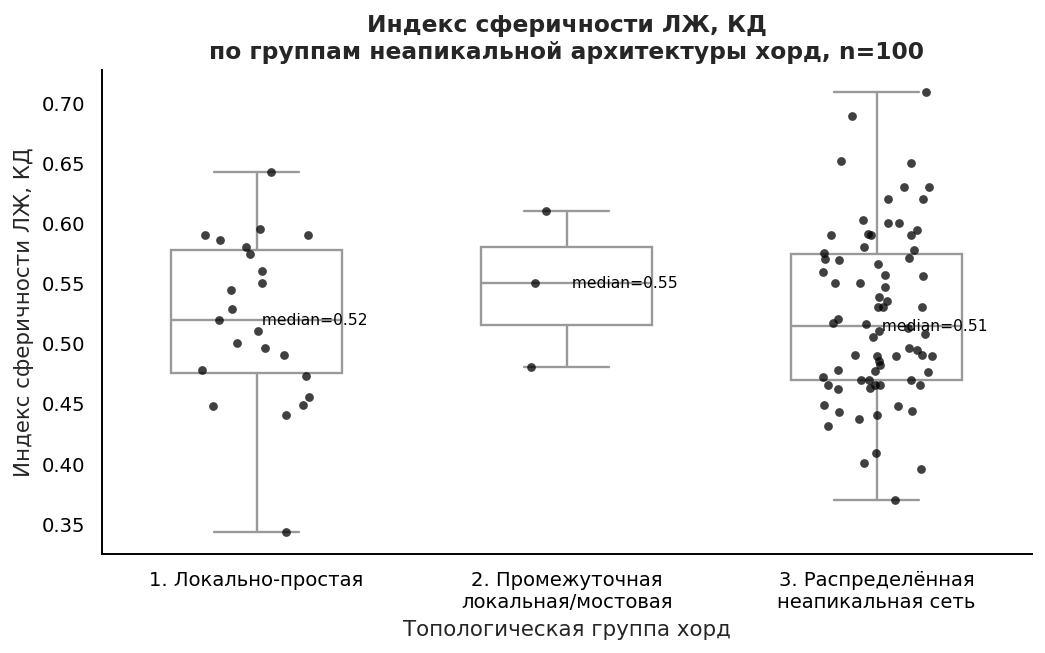

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_echo_lv_sphericity_index_end_systolic_ratio_by_non_apical_chord_topology.png


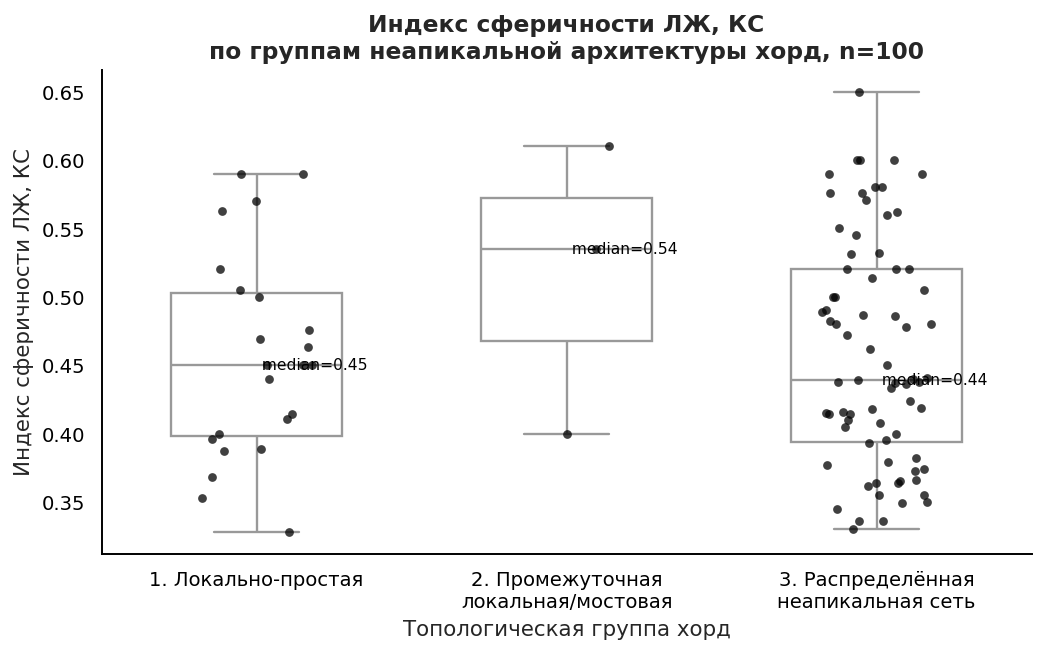

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_echo_lv_myocardial_mass_index_g_m2_by_non_apical_chord_topology.png


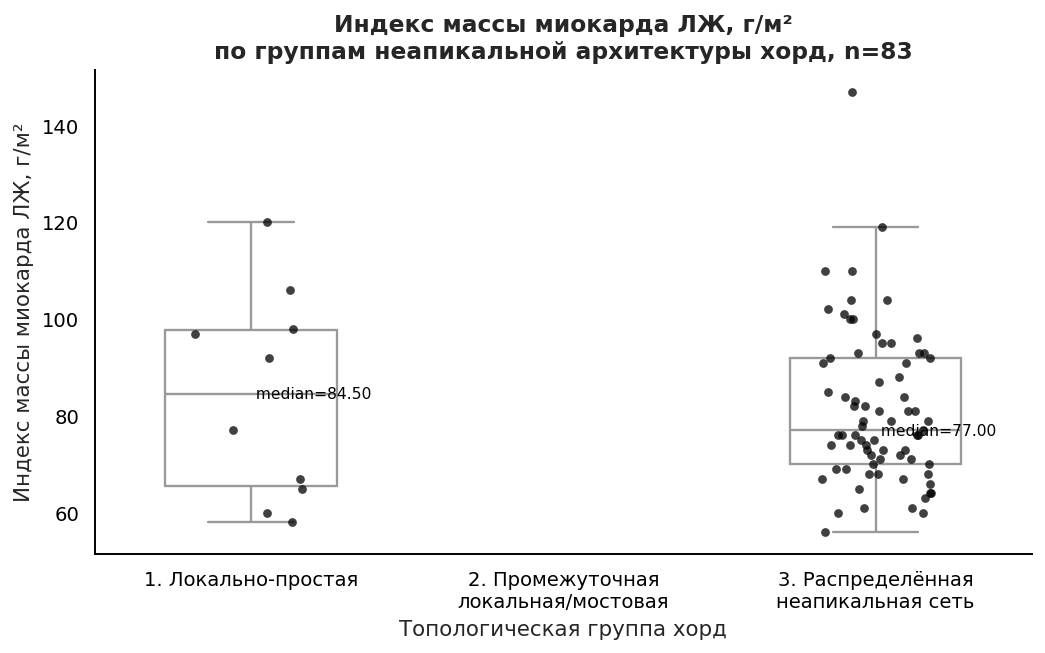

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_echo_lv_sws_delta_g_cm2_by_non_apical_chord_topology.png


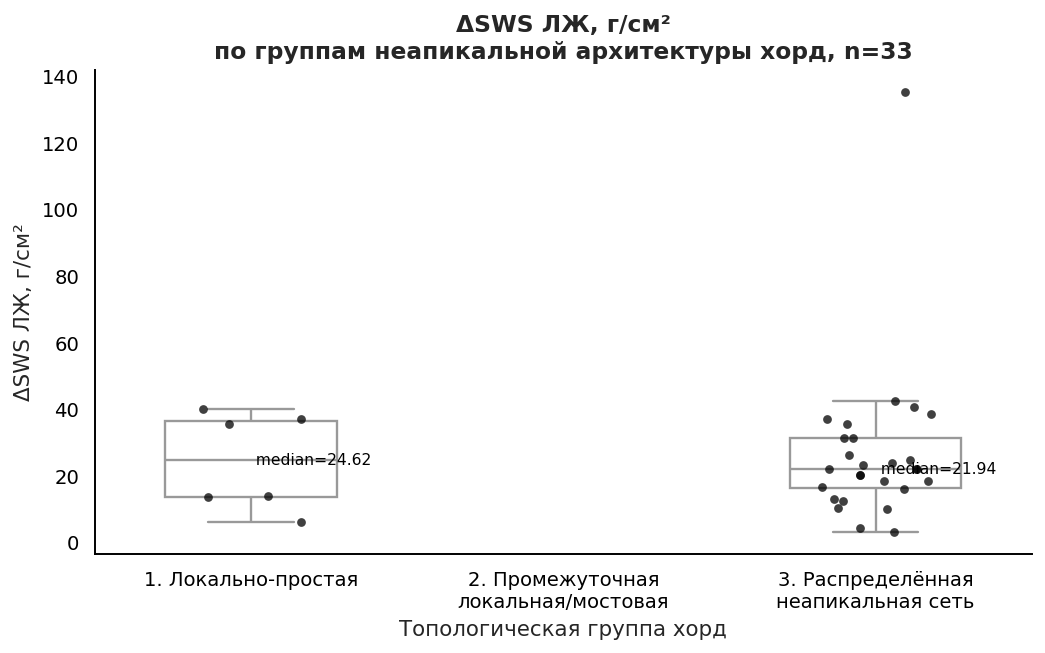

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_merged_lv_deformation_cv_pct_by_non_apical_chord_topology.png


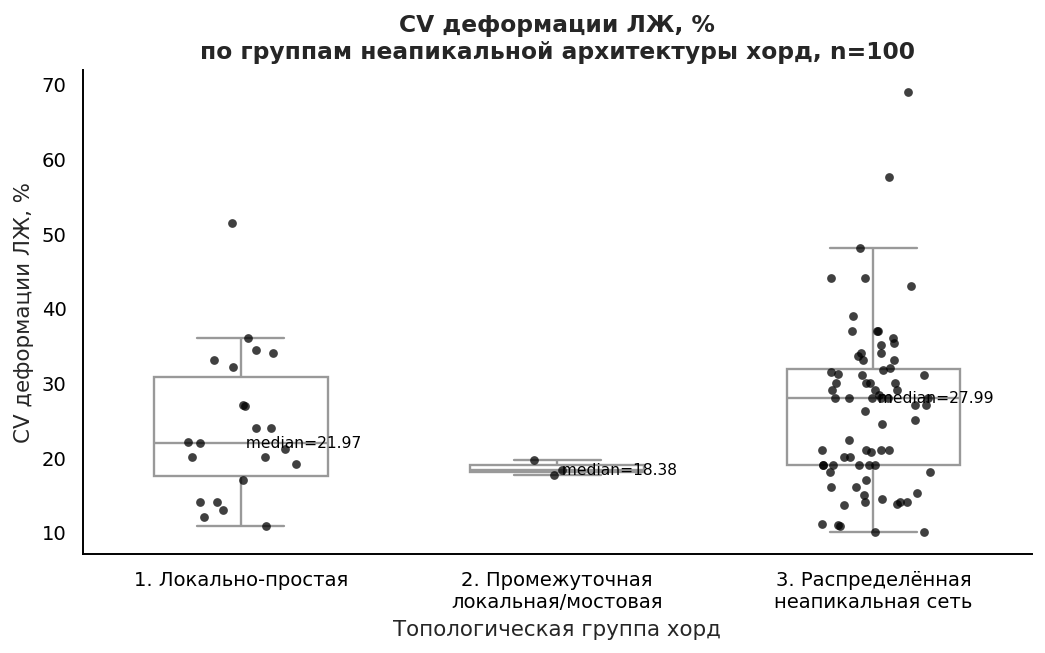

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_box_strip_dicor_sm_kdtr_cv_pct_by_non_apical_chord_topology.png


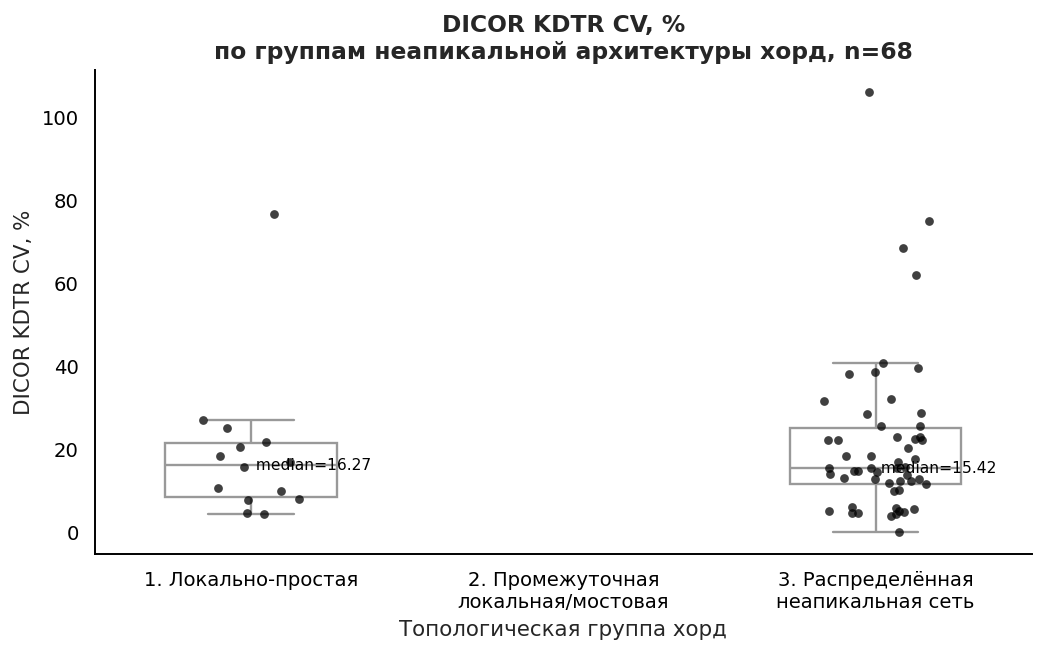

In [11]:
# ----------------------------
# Boxplot + stripplot for each outcome
# ----------------------------

def plot_outcome_by_topology_group(
    data,
    outcome,
    group_col="non_apical_chord_topology_group",
    save=True,
):
    temp = data[[group_col, outcome]].dropna().copy()
    temp = temp[temp[group_col].isin(GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    fig, ax = plt.subplots(figsize=(7.6, 4.8))

    sns.boxplot(
        data=temp,
        x=group_col,
        y=outcome,
        order=GROUP_ORDER,
        color="white",
        width=0.55,
        fliersize=0,
        linewidth=1.2,
        ax=ax,
    )

    sns.stripplot(
        data=temp,
        x=group_col,
        y=outcome,
        order=GROUP_ORDER,
        color="black",
        size=4.5,
        jitter=0.18,
        alpha=0.75,
        ax=ax,
    )

    # Add medians
    medians = temp.groupby(group_col)[outcome].median()
    for i, g in enumerate(GROUP_ORDER):
        if g in medians.index:
            ax.text(
                i,
                medians.loc[g],
                f" median={medians.loc[g]:.2f}",
                va="center",
                ha="left",
                fontsize=8,
                color="black",
            )

    ax.set_xlabel("Топологическая группа хорд")
    ax.set_ylabel(OUTCOME_LABELS_RU.get(outcome, outcome))
    ax.set_xticklabels([GROUP_LABELS_RU[g] for g in GROUP_ORDER], rotation=0)

    n_total = len(temp)
    ax.set_title(f"{OUTCOME_LABELS_RU.get(outcome, outcome)}\nпо группам неапикальной архитектуры хорд, n={n_total}")

    sns.despine(ax=ax)

    plt.tight_layout()

    if save:
        file_name = f"17_box_strip_{outcome}_by_non_apical_chord_topology.png"
        fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
        print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_outcomes:
    plot_outcome_by_topology_group(df, outcome)

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_standardized_outcome_profile_by_non_apical_chord_topology.png


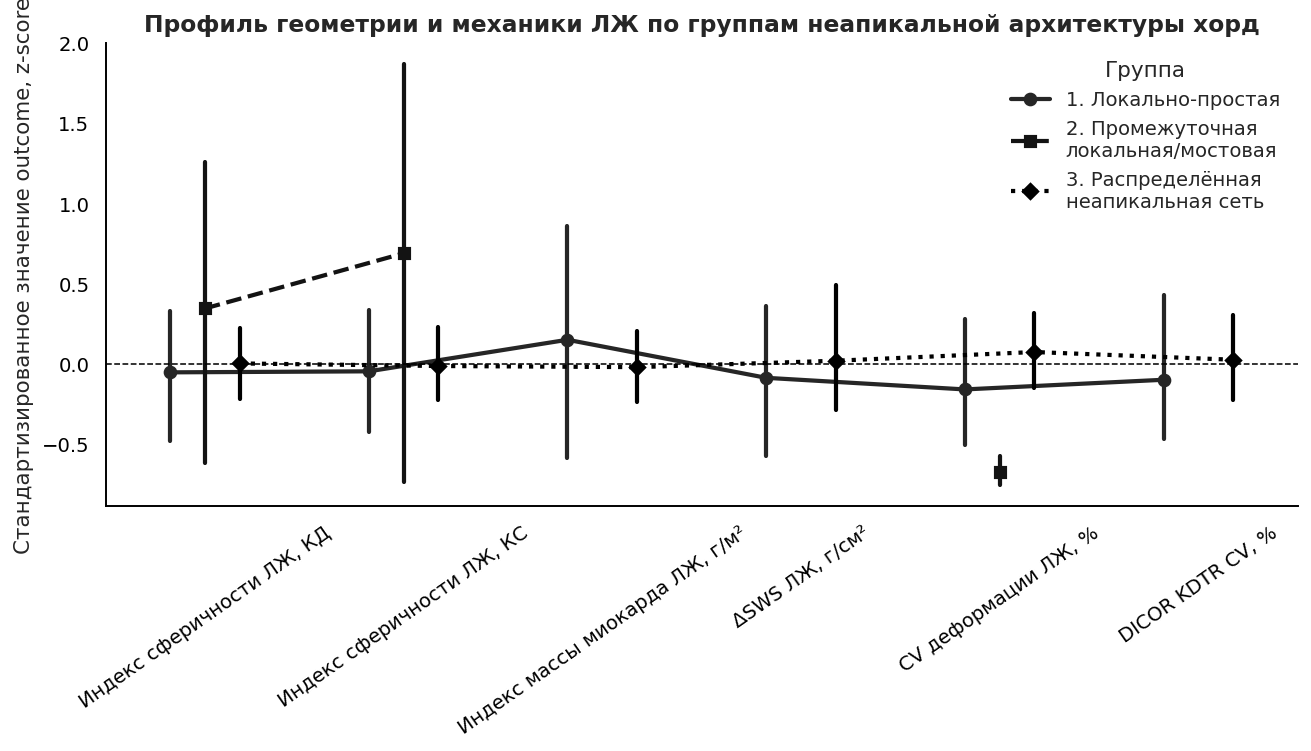

In [12]:
# ----------------------------
# Compact figure for quick comparison across outcomes
# ----------------------------

plot_data = []

for y in existing_outcomes:
    temp = df[["non_apical_chord_topology_group", y]].dropna().copy()
    temp = temp[temp["non_apical_chord_topology_group"].isin(GROUP_ORDER)]

    if temp.empty:
        continue

    # z-score for visual comparability only
    temp["z_value"] = (temp[y] - temp[y].mean()) / temp[y].std(ddof=0)
    temp["outcome"] = OUTCOME_LABELS_RU.get(y, y)
    plot_data.append(temp)

plot_data = pd.concat(plot_data, ignore_index=True)

fig, ax = plt.subplots(figsize=(9.5, 5.5))

sns.pointplot(
    data=plot_data,
    x="outcome",
    y="z_value",
    hue="non_apical_chord_topology_group",
    hue_order=GROUP_ORDER,
    errorbar=("ci", 95),
    dodge=0.35,
    markers=["o", "s", "D"],
    linestyles=["-", "--", ":"],
    color="black",
    ax=ax,
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("")
ax.set_ylabel("Стандартизированное значение outcome, z-score")
ax.set_title("Профиль геометрии и механики ЛЖ по группам неапикальной архитектуры хорд")
ax.tick_params(axis="x", rotation=35)

handles, labels = ax.get_legend_handles_labels()
new_labels = [GROUP_LABELS_RU.get(lbl, lbl) for lbl in labels]
ax.legend(handles, new_labels, title="Группа", loc="best")

sns.despine(ax=ax)
plt.tight_layout()

file_name = "17_standardized_outcome_profile_by_non_apical_chord_topology.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()

In [16]:
# ============================================================
# Create clean binary topology variable
# ============================================================

df["topology_binary_clean"] = np.nan

# Group 1: clean local-simple
df.loc[
    df["non_apical_chord_topology_group_v2"] == "1_Local_simple",
    "topology_binary_clean"
] = "1_Local_simple"

# Group 3: only true residual complex non-apical, without missing-count cases
df.loc[
    (df["non_apical_chord_topology_group_v2"] == "3_Distributed_non_apical_network")
    & (df["topology_classification_reason"] == "residual_complex_non_apical"),
    "topology_binary_clean"
] = "2_Complex_non_apical"

# Exclude group 2 and missing-count residuals from main clean comparison
display(
    df["topology_binary_clean"]
    .value_counts(dropna=False)
    .rename_axis("topology_binary_clean")
    .reset_index(name="n")
)

,topology_binary_clean,n
0,2_Complex_non_apical,101
1,1_Local_simple,28
2,NaN,24


In [18]:
# ============================================================
# CLEAN BINARY ANALYSIS:
# Local-simple vs Complex non-apical
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Basic settings
# ------------------------------------------------------------

CLEAN_GROUP_COL = "topology_binary_clean"

CLEAN_GROUP_ORDER = [
    "1_Local_simple",
    "2_Complex_non_apical",
]

CLEAN_GROUP_LABELS_RU = {
    "1_Local_simple": "1. Локально-простая",
    "2_Complex_non_apical": "2. Сложная\nнеапикальная",
}

OUTCOMES = [
    "echo_lv_sphericity_index_end_diastolic_ratio",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_myocardial_mass_index_g_m2",
    "echo_lv_sws_delta_g_cm2",
    "merged_lv_deformation_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

OUTCOME_LABELS_RU = {
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_myocardial_mass_index_g_m2": "Индекс массы миокарда ЛЖ, г/м²",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "merged_lv_deformation_cv_pct": "CV деформации ЛЖ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR KDTR CV, %",
}

# Если директории уже были созданы выше — код их просто использует.
try:
    FIGURES_DIR
except NameError:
    FIGURES_DIR = Path("output") / "figures"
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

try:
    TABLES_DIR
except NameError:
    TABLES_DIR = Path("output") / "tables"
    TABLES_DIR.mkdir(parents=True, exist_ok=True)

existing_outcomes = [c for c in OUTCOMES if c in df.columns]

for col in existing_outcomes:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Outcomes found:")
print(existing_outcomes)

print("\nClean group counts:")
display(
    df[CLEAN_GROUP_COL]
    .value_counts(dropna=False)
    .rename_axis(CLEAN_GROUP_COL)
    .reset_index(name="n")
)

Outcomes found:
['echo_lv_sphericity_index_end_diastolic_ratio', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_myocardial_mass_index_g_m2', 'echo_lv_sws_delta_g_cm2', 'merged_lv_deformation_cv_pct', 'dicor_sm_kdtr_cv_pct']

Clean group counts:


,topology_binary_clean,n
0,2_Complex_non_apical,101
1,1_Local_simple,28
2,NaN,24


In [19]:
# ============================================================
# 2. Outcome availability by clean binary groups
# ============================================================

rows = []

for y in existing_outcomes:
    temp = df[[CLEAN_GROUP_COL, y]].dropna().copy()
    temp = temp[temp[CLEAN_GROUP_COL].isin(CLEAN_GROUP_ORDER)]

    counts = temp[CLEAN_GROUP_COL].value_counts().to_dict()

    rows.append({
        "outcome": y,
        "outcome_label_ru": OUTCOME_LABELS_RU.get(y, y),
        "n_total": len(temp),
        "n_local_simple": counts.get("1_Local_simple", 0),
        "n_complex_non_apical": counts.get("2_Complex_non_apical", 0),
    })

n_by_outcome_clean = pd.DataFrame(rows)

display(n_by_outcome_clean)

n_by_outcome_clean.to_excel(
    TABLES_DIR / "17_clean_binary_outcome_availability.xlsx",
    index=False
)

,outcome,outcome_label_ru,n_total,n_local_simple,n_complex_non_apical
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",90,23,67
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",90,23,67
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",77,10,67
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",29,6,23
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",90,22,68
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",65,14,51


In [20]:
# ============================================================
# 3. Descriptive statistics + Mann-Whitney + Cliff's delta
# ============================================================

def cliffs_delta(x, y):
    x = np.asarray(pd.Series(x).dropna())
    y = np.asarray(pd.Series(y).dropna())

    if len(x) == 0 or len(y) == 0:
        return np.nan

    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)

    return (gt - lt) / (len(x) * len(y))


summary_rows = []
test_rows = []

for outcome in existing_outcomes:
    temp = df[[CLEAN_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[CLEAN_GROUP_COL].isin(CLEAN_GROUP_ORDER)]

    if temp.empty:
        continue

    # Descriptive statistics
    desc = (
        temp
        .groupby(CLEAN_GROUP_COL)[outcome]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )
    desc["outcome"] = outcome
    desc["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)
    summary_rows.append(desc)

    x = temp.loc[temp[CLEAN_GROUP_COL] == "1_Local_simple", outcome].dropna()
    y = temp.loc[temp[CLEAN_GROUP_COL] == "2_Complex_non_apical", outcome].dropna()

    if len(x) >= 2 and len(y) >= 2:
        u_stat, p_value = stats.mannwhitneyu(x, y, alternative="two-sided")
        cliff = cliffs_delta(x, y)
    else:
        u_stat, p_value, cliff = np.nan, np.nan, np.nan

    test_rows.append({
        "outcome": outcome,
        "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
        "n_local_simple": len(x),
        "n_complex_non_apical": len(y),
        "median_local_simple": np.nanmedian(x) if len(x) else np.nan,
        "median_complex_non_apical": np.nanmedian(y) if len(y) else np.nan,
        "median_diff_complex_minus_local": (
            np.nanmedian(y) - np.nanmedian(x)
            if len(x) and len(y)
            else np.nan
        ),
        "mannwhitney_u": u_stat,
        "p_value": p_value,
        "cliffs_delta_local_vs_complex": cliff,
    })

summary_clean = pd.concat(summary_rows, ignore_index=True)
tests_clean = pd.DataFrame(test_rows)

display(summary_clean)
display(tests_clean.sort_values("p_value"))

summary_clean.to_excel(
    TABLES_DIR / "17_clean_binary_descriptive_stats.xlsx",
    index=False
)

tests_clean.to_excel(
    TABLES_DIR / "17_clean_binary_mannwhitney_tests.xlsx",
    index=False
)

,topology_binary_clean,count,mean,std,median,min,max,outcome,outcome_label_ru
0,1_Local_simple,23,0.519130,0.068235,0.519000,0.343000,0.642000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
1,2_Complex_non_apical,67,0.525821,0.067981,0.516000,0.370000,0.709000,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД"
2,1_Local_simple,23,0.455739,0.075161,0.450000,0.328000,0.590000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
3,2_Complex_non_apical,67,0.460657,0.078786,0.441000,0.336000,0.600000,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС"
4,1_Local_simple,10,84.000000,21.499354,84.500000,58.000000,120.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²"
5,2_Complex_non_apical,67,80.910448,15.790994,77.000000,56.000000,147.000000,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²"
6,1_Local_simple,6,24.255056,14.732182,24.615650,5.994872,39.878423,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²"
7,2_Complex_non_apical,23,27.912081,25.796953,22.112423,3.042909,135.312821,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²"
8,1_Local_simple,22,23.990145,9.826475,21.967337,10.835993,51.438233,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %"
9,2_Complex_non_apical,68,26.997406,11.048274,28.000000,10.000000,69.000000,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %"


,outcome,outcome_label_ru,n_local_simple,n_complex_non_apical,median_local_simple,median_complex_non_apical,median_diff_complex_minus_local,mannwhitney_u,p_value,cliffs_delta_local_vs_complex
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",22,68,21.967337,28.000000,6.032663,631.0,0.273810,-0.156417
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",14,51,16.269940,15.384615,-0.885324,329.5,0.666524,-0.077031
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",10,67,84.500000,77.000000,-7.500000,351.5,0.808368,0.049254
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",23,67,0.450000,0.441000,-0.009000,750.0,0.853194,-0.026606
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",6,23,24.615650,22.112423,-2.503228,66.0,0.895760,-0.043478
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",23,67,0.519000,0.516000,-0.003000,759.5,0.922608,-0.014276


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_echo_lv_sphericity_index_end_diastolic_ratio_by_topology.png


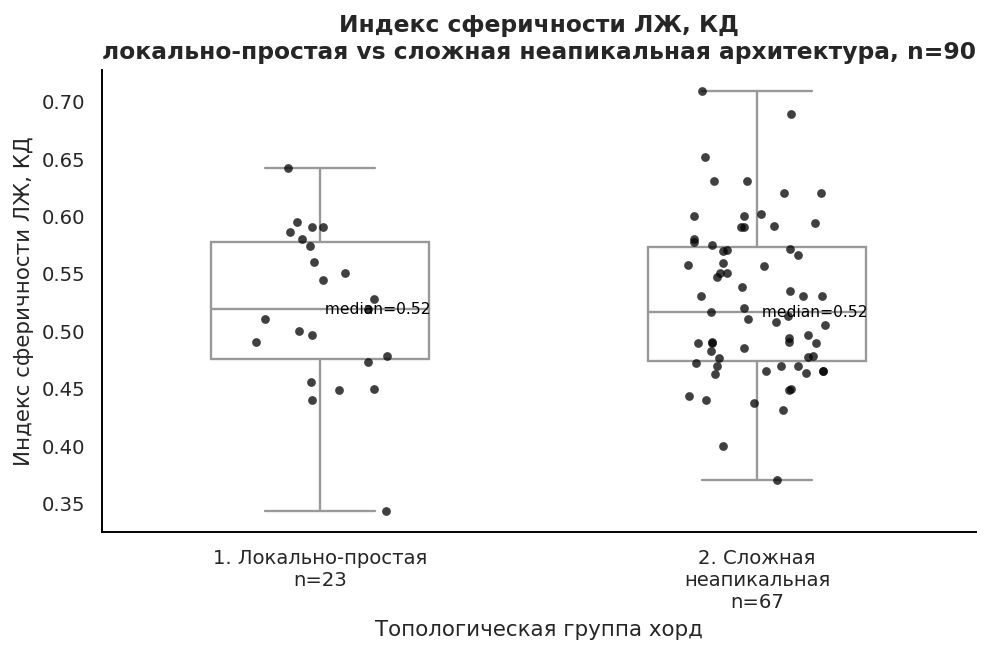

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_echo_lv_sphericity_index_end_systolic_ratio_by_topology.png


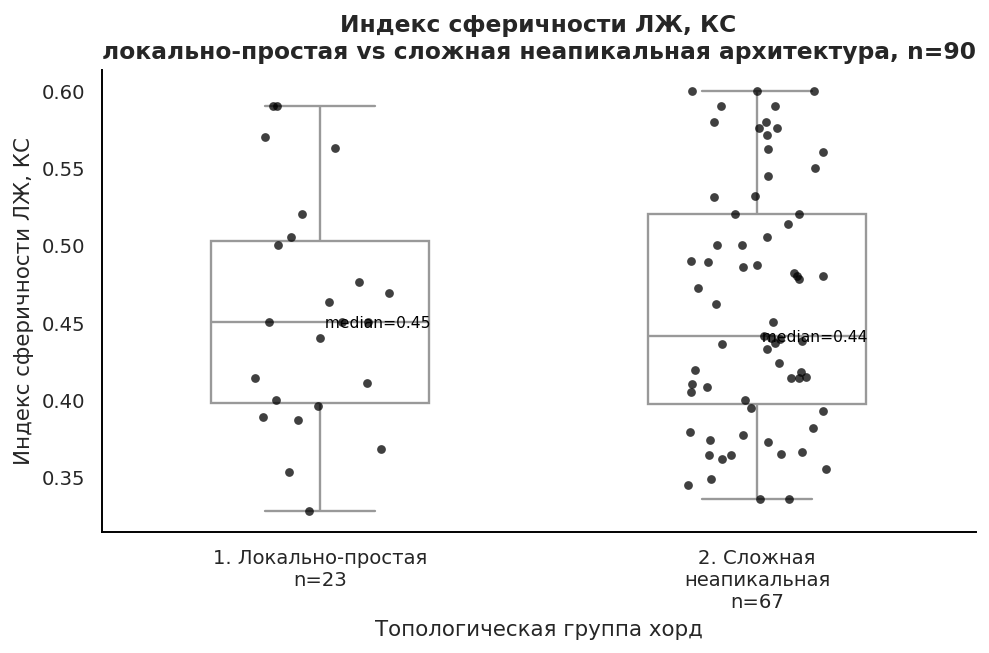

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_echo_lv_myocardial_mass_index_g_m2_by_topology.png


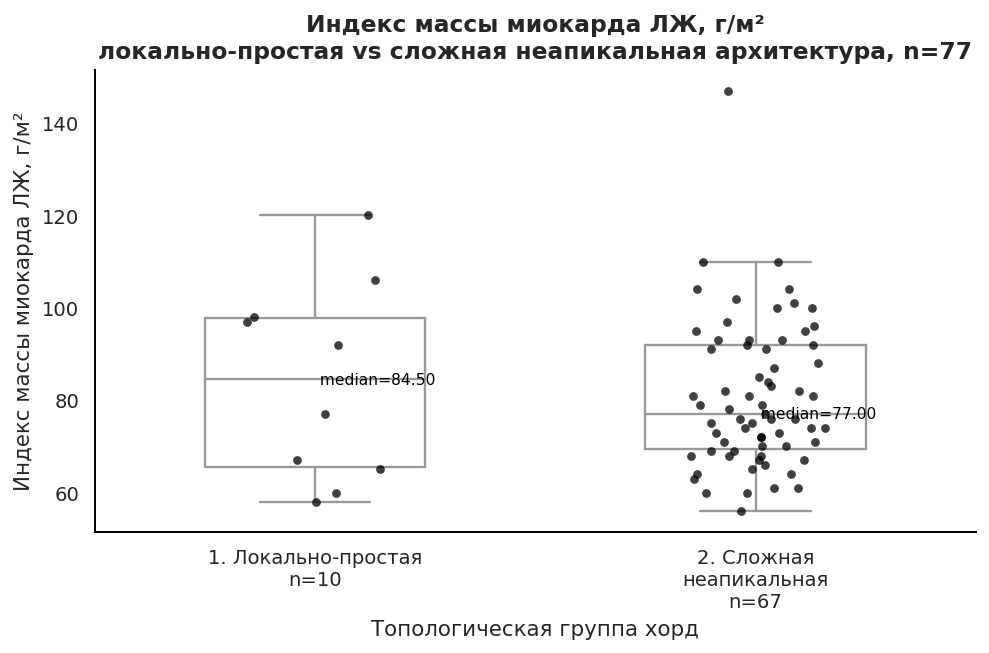

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_echo_lv_sws_delta_g_cm2_by_topology.png


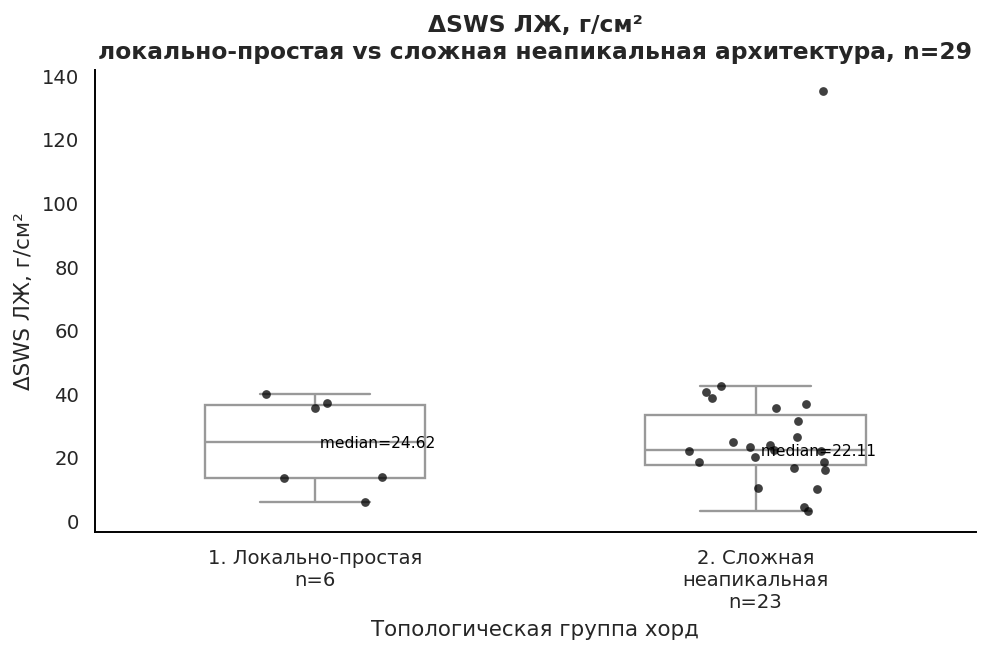

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_merged_lv_deformation_cv_pct_by_topology.png


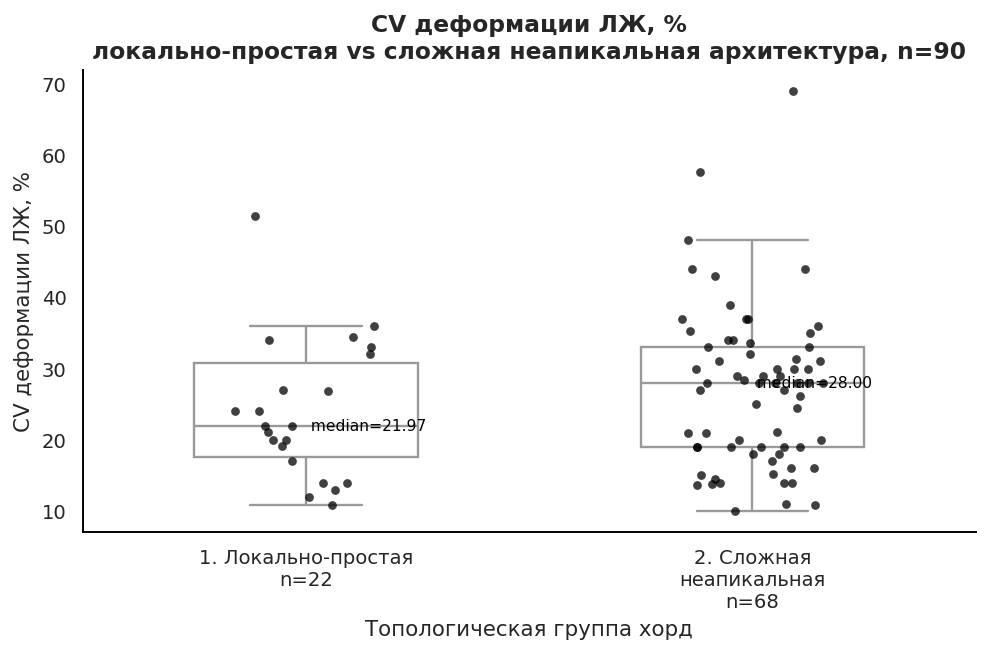

Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_dicor_sm_kdtr_cv_pct_by_topology.png


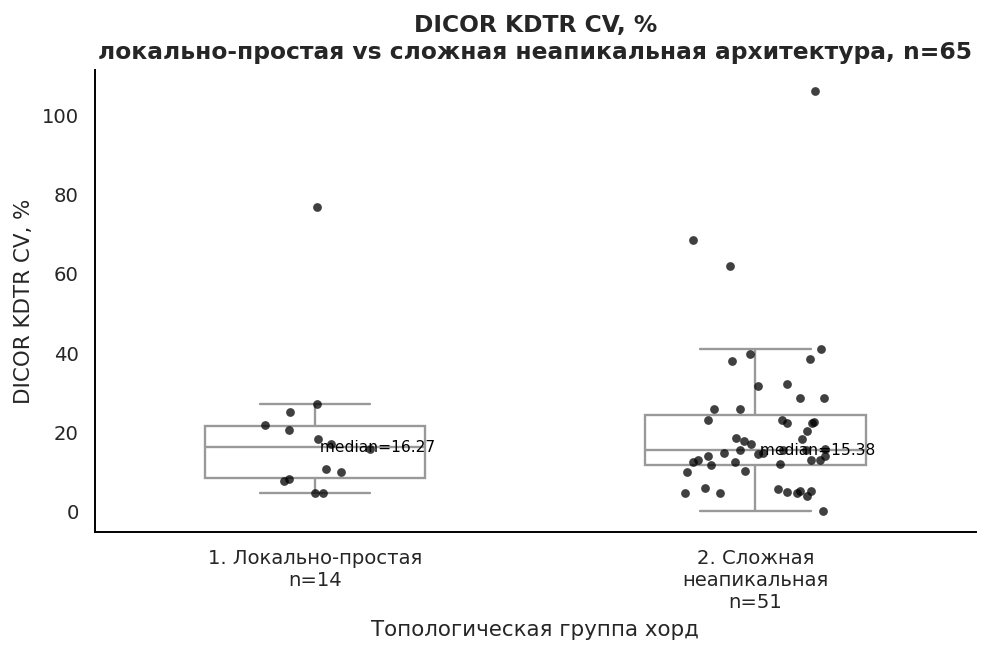

In [21]:
# ============================================================
# 4. Academic boxplot + stripplot for clean binary groups
# ============================================================

sns.set_theme(context="paper", style="white", font_scale=1.15)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "figure.figsize": (7.2, 4.8),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
})


def plot_clean_binary_outcome(data, outcome):
    temp = data[[CLEAN_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[CLEAN_GROUP_COL].isin(CLEAN_GROUP_ORDER)]

    if temp.empty:
        print(f"Skipping {outcome}: no data")
        return

    group_n = temp[CLEAN_GROUP_COL].value_counts().to_dict()

    xlabels = [
        f"{CLEAN_GROUP_LABELS_RU[g]}\nn={group_n.get(g, 0)}"
        for g in CLEAN_GROUP_ORDER
    ]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    sns.boxplot(
        data=temp,
        x=CLEAN_GROUP_COL,
        y=outcome,
        order=CLEAN_GROUP_ORDER,
        color="white",
        width=0.50,
        fliersize=0,
        linewidth=1.2,
        ax=ax,
    )

    sns.stripplot(
        data=temp,
        x=CLEAN_GROUP_COL,
        y=outcome,
        order=CLEAN_GROUP_ORDER,
        color="black",
        size=4.5,
        jitter=0.16,
        alpha=0.75,
        ax=ax,
    )

    medians = temp.groupby(CLEAN_GROUP_COL)[outcome].median()

    for i, g in enumerate(CLEAN_GROUP_ORDER):
        if g in medians.index:
            ax.text(
                i,
                medians.loc[g],
                f" median={medians.loc[g]:.2f}",
                va="center",
                ha="left",
                fontsize=8,
                color="black",
            )

    ax.set_xlabel("Топологическая группа хорд")
    ax.set_ylabel(OUTCOME_LABELS_RU.get(outcome, outcome))
    ax.set_xticklabels(xlabels)

    ax.set_title(
        f"{OUTCOME_LABELS_RU.get(outcome, outcome)}\n"
        f"локально-простая vs сложная неапикальная архитектура, n={len(temp)}"
    )

    sns.despine(ax=ax)
    plt.tight_layout()

    file_name = f"17_clean_binary_{outcome}_by_topology.png"
    fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
    print("Saved:", FIGURES_DIR / file_name)

    plt.show()


for outcome in existing_outcomes:
    plot_clean_binary_outcome(df, outcome)

In [22]:
# ============================================================
# 5. Robust OLS models: clean binary topology vs outcomes
# ============================================================

model_rows = []

for outcome in existing_outcomes:
    temp = df[[CLEAN_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[CLEAN_GROUP_COL].isin(CLEAN_GROUP_ORDER)]

    if temp[CLEAN_GROUP_COL].nunique() < 2 or len(temp) < 10:
        continue

    temp[CLEAN_GROUP_COL] = pd.Categorical(
        temp[CLEAN_GROUP_COL],
        categories=CLEAN_GROUP_ORDER,
        ordered=True,
    )

    formula = (
        f"{outcome} ~ "
        f"C({CLEAN_GROUP_COL}, Treatment(reference='1_Local_simple'))"
    )

    model = smf.ols(formula, data=temp).fit(cov_type="HC3")

    term = [
        t for t in model.params.index
        if "2_Complex_non_apical" in t
    ]

    if len(term) == 1:
        term = term[0]

        model_rows.append({
            "outcome": outcome,
            "outcome_label_ru": OUTCOME_LABELS_RU.get(outcome, outcome),
            "n": int(model.nobs),
            "coef_complex_vs_local": model.params[term],
            "p_value_hc3": model.pvalues[term],
            "ci_low_hc3": model.conf_int().loc[term, 0],
            "ci_high_hc3": model.conf_int().loc[term, 1],
            "r2": model.rsquared,
            "adj_r2": model.rsquared_adj,
        })

models_clean = pd.DataFrame(model_rows)

display(models_clean.sort_values("p_value_hc3"))

models_clean.to_excel(
    TABLES_DIR / "17_clean_binary_robust_ols_models.xlsx",
    index=False
)

,outcome,outcome_label_ru,n,coef_complex_vs_local,p_value_hc3,ci_low_hc3,ci_high_hc3,r2,adj_r2
4,merged_lv_deformation_cv_pct,"CV деформации ЛЖ, %",90,3.007261,0.235276,-1.958814,7.973337,0.014515,0.003317
3,echo_lv_sws_delta_g_cm2,"ΔSWS ЛЖ, г/см²",29,3.657025,0.670028,-13.164063,20.478113,0.004031,-0.032857
2,echo_lv_myocardial_mass_index_g_m2,"Индекс массы миокарда ЛЖ, г/м²",77,-3.089552,0.677351,-17.643012,11.463908,0.004012,-0.009268
0,echo_lv_sphericity_index_end_diastolic_ratio,"Индекс сферичности ЛЖ, КД",90,0.006690,0.690150,-0.026203,0.039584,0.001878,-0.009465
5,dicor_sm_kdtr_cv_pct,"DICOR KDTR CV, %",65,1.597372,0.777526,-9.483325,12.678069,0.001328,-0.014524
1,echo_lv_sphericity_index_end_systolic_ratio,"Индекс сферичности ЛЖ, КС",90,0.004918,0.792902,-0.031794,0.041629,0.000775,-0.010580


Saved: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\output\figures\17_clean_binary_standardized_profile.png


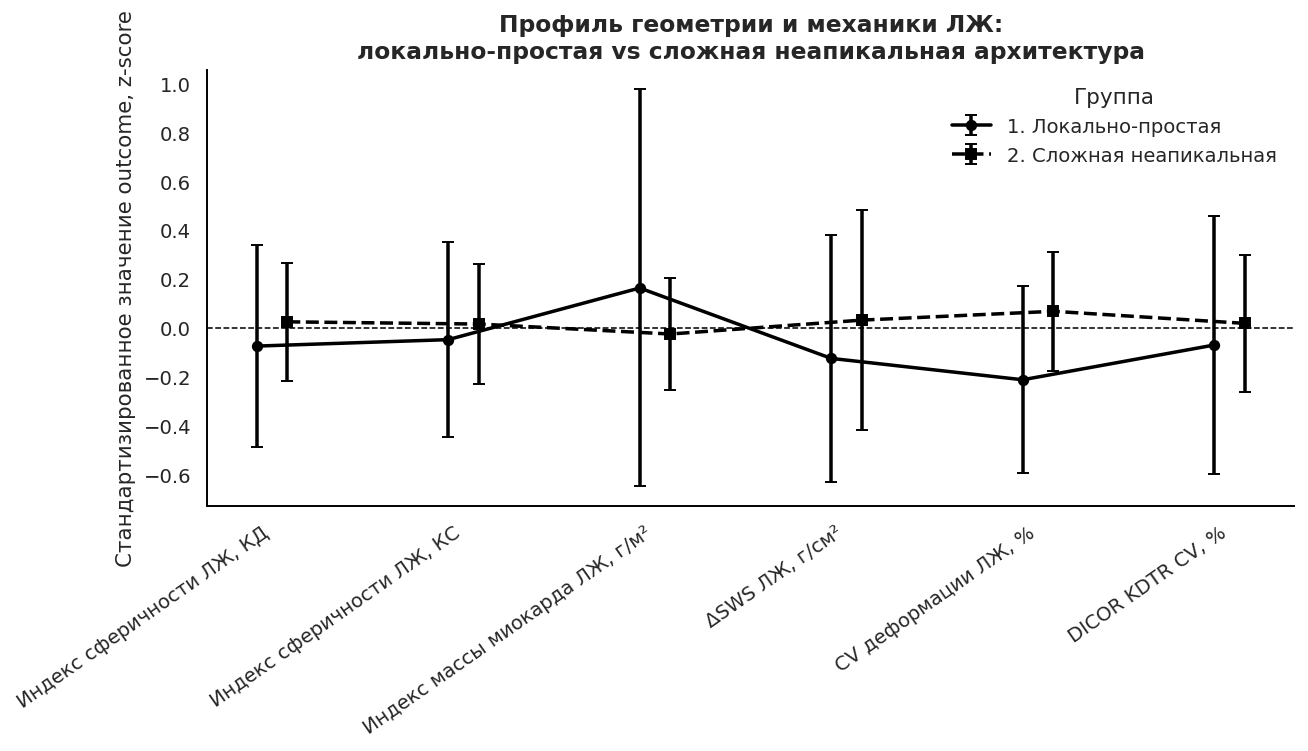

In [23]:
# ============================================================
# 6. Compact standardized profile plot
# ============================================================

profile_rows = []

for outcome in existing_outcomes:
    temp = df[[CLEAN_GROUP_COL, outcome]].dropna().copy()
    temp = temp[temp[CLEAN_GROUP_COL].isin(CLEAN_GROUP_ORDER)]

    if temp.empty or temp[outcome].std(ddof=0) == 0:
        continue

    temp["z_value"] = (temp[outcome] - temp[outcome].mean()) / temp[outcome].std(ddof=0)
    temp["outcome_label_ru"] = OUTCOME_LABELS_RU.get(outcome, outcome)

    grouped = (
        temp
        .groupby([CLEAN_GROUP_COL, "outcome_label_ru"])["z_value"]
        .agg(["mean", "sem", "count"])
        .reset_index()
    )

    profile_rows.append(grouped)

profile_df = pd.concat(profile_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(9.5, 5.5))

x_labels = list(profile_df["outcome_label_ru"].drop_duplicates())
x_positions = np.arange(len(x_labels))

offsets = {
    "1_Local_simple": -0.08,
    "2_Complex_non_apical": 0.08,
}

markers = {
    "1_Local_simple": "o",
    "2_Complex_non_apical": "s",
}

linestyles = {
    "1_Local_simple": "-",
    "2_Complex_non_apical": "--",
}

for group in CLEAN_GROUP_ORDER:
    gdf = profile_df[profile_df[CLEAN_GROUP_COL] == group].copy()

    y_values = []
    y_errors = []

    for label in x_labels:
        row = gdf[gdf["outcome_label_ru"] == label]

        if row.empty:
            y_values.append(np.nan)
            y_errors.append(np.nan)
        else:
            y_values.append(row["mean"].iloc[0])
            y_errors.append(row["sem"].iloc[0] * 1.96)

    ax.errorbar(
        x_positions + offsets[group],
        y_values,
        yerr=y_errors,
        marker=markers[group],
        linestyle=linestyles[group],
        linewidth=1.8,
        capsize=3,
        color="black",
        label=CLEAN_GROUP_LABELS_RU[group].replace("\n", " "),
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=35, ha="right")

ax.set_ylabel("Стандартизированное значение outcome, z-score")
ax.set_xlabel("")
ax.set_title(
    "Профиль геометрии и механики ЛЖ:\n"
    "локально-простая vs сложная неапикальная архитектура"
)

ax.legend(title="Группа")
sns.despine(ax=ax)

plt.tight_layout()

file_name = "17_clean_binary_standardized_profile.png"
fig.savefig(FIGURES_DIR / file_name, bbox_inches="tight")
print("Saved:", FIGURES_DIR / file_name)

plt.show()